https://gispub.epa.gov/airnow

Download file from above, using the date and the type of data
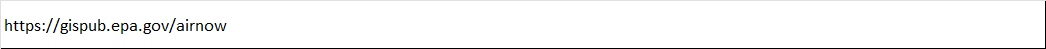
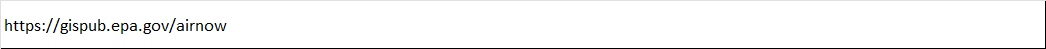
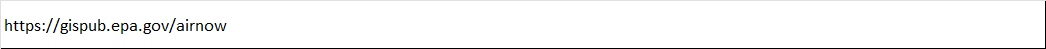
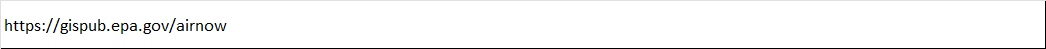

In [1]:
# Import necessary libraries for data processing and spatial operations.
import os  # For handling file paths.
import pandas as pd  # For handling tabular data (CSV files).
import numpy as np  # For numerical operations and array manipulations.
from datetime import datetime  # For handling dates and timestamps.
import scipy
from scipy.spatial import KDTree  # For efficient spatial queries using KD-tree.
import sys  # For accessing the Python version.

# Debug: Confirm that imports are successful.
print("Debug: Libraries imported successfully.")

# Print the versions of Python and each imported module.
print(f"Python version: {sys.version}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"scipy version: {scipy.__version__}")
# Note: os and datetime are part of Python's standard library and do not have separate versions.

Debug: Libraries imported successfully.
Python version: 3.10.12 (main, Nov  6 2024, 20:22:13) [GCC 11.4.0]
pandas version: 2.2.3
numpy version: 1.26.4
scipy version: 1.13.1


In [2]:
# Define directory paths for Kaggle environment.
base_dir = r"/kaggle/input/eyds-base-dataset"  # Base directory for input datasets.
sub_dir = r"/kaggle/working/"  # Submission directory for output files.

# Define file paths for input datasets.
aq_files = {
    "SO2": {
        "file": f"{base_dir}/AQ/S02.csv",
        "date_col": "Date",
        "value_col": "Daily Max 1-hour SO2 Concentration",
        "lat_col": "Site Latitude",
        "lon_col": "Site Longitude"
    },
    "Ozone": {
        "file": f"{base_dir}/AQ/Ozone.csv",
        "date_col": "Date",
        "value_col": "Daily Max 8-hour Ozone Concentration",
        "lat_col": "Site Latitude",
        "lon_col": "Site Longitude"
    },
    "CO": {
        "file": f"{base_dir}/AQ/CO.csv",
        "date_col": "Date",
        "value_col": "Daily Max 8-hour CO Concentration",
        "lat_col": "Site Latitude",
        "lon_col": "Site Longitude"
    },
    "NO2": {
        "file": f"{base_dir}/AQ/NO2.csv",
        "date_col": "Date",
        "value_col": "Daily Max 1-hour NO2 Concentration",
        "lat_col": "Site Latitude",
        "lon_col": "Site Longitude"
    },
    "PM10": {
        "file": f"{base_dir}/AQ/pm10.csv",
        "date_col": "Date",
        "value_col": "Daily Mean PM10 Concentration",
        "lat_col": "Site Latitude",
        "lon_col": "Site Longitude"
    },
    "PM2.5": {
        "file": f"{base_dir}/AQ/pm2.5.csv",
        "date_col": "Date",
        "value_col": "Daily Mean PM2.5 Concentration",
        "lat_col": "Site Latitude",
        "lon_col": "Site Longitude"
    }
}

train_file = f"{base_dir}/Training_data.csv"
valid_file = f"{base_dir}/Validation_data.csv"

# Define output file paths for enriched datasets.
output_train_csv = f"{sub_dir}/Training_data_enriched.csv"
output_valid_csv = f"{sub_dir}/Validation_data_enriched.csv"

# Debug: Print the file paths to confirm they are set correctly.
print("Debug: Air Quality file paths:")
for key, params in aq_files.items():
    print(f" - {key}: {params['file']}")
print(f"Debug: Training file path: {train_file}")
print(f"Debug: Validation file path: {valid_file}")
print(f"Debug: Output training CSV path: {output_train_csv}")
print(f"Debug: Output validation CSV path: {output_valid_csv}")

Debug: Air Quality file paths:
 - SO2: /kaggle/input/eyds-base-dataset/AQ/S02.csv
 - Ozone: /kaggle/input/eyds-base-dataset/AQ/Ozone.csv
 - CO: /kaggle/input/eyds-base-dataset/AQ/CO.csv
 - NO2: /kaggle/input/eyds-base-dataset/AQ/NO2.csv
 - PM10: /kaggle/input/eyds-base-dataset/AQ/pm10.csv
 - PM2.5: /kaggle/input/eyds-base-dataset/AQ/pm2.5.csv
Debug: Training file path: /kaggle/input/eyds-base-dataset/Training_data.csv
Debug: Validation file path: /kaggle/input/eyds-base-dataset/Validation_data.csv
Debug: Output training CSV path: /kaggle/working//Training_data_enriched.csv
Debug: Output validation CSV path: /kaggle/working//Validation_data_enriched.csv


In [3]:
def load_and_aggregate_aq_data(file_path, date_col, value_col, lat_col, lon_col):
    """
    Load an air quality CSV, convert the date column, filter for June–August,
    and compute descriptive statistics per site including:
      - Mean, median, standard deviation, minimum, maximum,
        25th and 75th percentiles for the summer period.
      - The pollutant value closest to 21 July 2021.
    
    Parameters:
        file_path (str): Path to the air quality CSV file.
        date_col (str): Name of the column containing date information.
        value_col (str): Name of the column containing the pollutant concentration.
        lat_col (str): Name of the column containing latitude.
        lon_col (str): Name of the column containing longitude.
    
    Returns:
        pd.DataFrame: DataFrame keyed by [lat_col, lon_col] with new columns prefixed
                      by the file's base name, containing aggregated statistics.
    """
    # Read the AQ data.
    print(f"Loading air quality data from {file_path}...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: Air quality file not found at {file_path}")
        return None

    # Debug: Print the shape and columns of the loaded AQ data.
    print(f"Debug: AQ DataFrame shape: {df.shape}")
    print(f"Debug: AQ DataFrame columns: {df.columns.tolist()}")

    # Convert date column to datetime.
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Filter for summer months: June, July, August.
    df_jja = df[df[date_col].dt.month.isin([6, 7, 8])].copy()
    
    # Debug: Print the shape after filtering for summer months.
    print(f"Debug: AQ DataFrame shape after filtering for June-August: {df_jja.shape}")

    # Compute descriptive statistics per site.
    agg_stats = df_jja.groupby([lat_col, lon_col])[value_col].agg(
        avg_JJA=np.mean,
        median_JJA=np.median,
        std_JJA=np.std,
        min_JJA=np.min,
        max_JJA=np.max,
        p25_JJA=lambda x: np.percentile(x, 25),
        p75_JJA=lambda x: np.percentile(x, 75)
    ).reset_index()
    
    # Debug: Print a sample of the aggregated statistics.
    print(f"Debug: Sample of aggregated statistics:\n{agg_stats.head()}")

    # Use the file's base name to prefix the statistic columns.
    base = os.path.splitext(os.path.basename(file_path))[0]
    agg_stats = agg_stats.rename(columns={
        "avg_JJA": f"{base}_avg_JJA",
        "median_JJA": f"{base}_median_JJA",
        "std_JJA": f"{base}_std_JJA",
        "min_JJA": f"{base}_min_JJA",
        "max_JJA": f"{base}_max_JJA",
        "p25_JJA": f"{base}_p25_JJA",
        "p75_JJA": f"{base}_p75_JJA"
    })
    
    # Define target date for specific extraction.
    target_date = pd.Timestamp("2021-07-21")
    
    # For each site, get the measurement closest in time to target_date.
    def get_nearest_value(group):
        group['date_diff'] = (group[date_col] - target_date).abs()
        nearest = group.loc[group['date_diff'].idxmin()]
        return nearest[value_col]
    
    aq_21 = df_jja.groupby([lat_col, lon_col]).apply(get_nearest_value).reset_index()
    aq_21.columns = [lat_col, lon_col, f"{base}_val_21Jul2021"]
    
    # Debug: Print a sample of the 21 July values.
    print(f"Debug: Sample of 21 July values:\n{aq_21.head()}")

    # Merge the descriptive statistics with the 21 July value per site.
    merged = pd.merge(agg_stats, aq_21, on=[lat_col, lon_col], how="outer")
    
    # Debug: Print the shape of the merged DataFrame.
    print(f"Debug: Merged AQ DataFrame shape: {merged.shape}")
    
    return merged

In [4]:
def print_unique_values(df, df_name):
    """
    Print a summary of unique values for each column in the dataframe.
    For columns with more than 10 unique values, print only the first 10 values.
    
    Parameters:
        df (pd.DataFrame): DataFrame to analyze.
        df_name (str): Name of the DataFrame for display purposes.
    """
    print(f"\nUnique values for '{df_name}':")
    for col in df.columns:
        uniq = df[col].unique()
        if len(uniq) > 10:
            print(f" - {col} ({len(uniq)} unique values): {uniq[:10]} ...")
        else:
            print(f" - {col} ({len(uniq)} unique values): {uniq}")

In [5]:
# Process each AQ file and store aggregated results in a dictionary.
aq_aggregated = {}
for key, params in aq_files.items():
    print(f"Processing {key} air quality data...")
    result = load_and_aggregate_aq_data(
        file_path=params["file"],
        date_col=params["date_col"],
        value_col=params["value_col"],
        lat_col=params["lat_col"],
        lon_col=params["lon_col"]
    )
    if result is None:
        print(f"Error: Failed to process {key} data. Skipping...")
        continue
    aq_aggregated[key] = result

# Debug: Print the keys of the aggregated AQ data.
print(f"Debug: Aggregated AQ data keys: {list(aq_aggregated.keys())}")

# Merge all the aggregated AQ DataFrames on [Site Latitude, Site Longitude].
merged_aq = None
for key, df in aq_aggregated.items():
    if merged_aq is None:
        merged_aq = df
    else:
        print(f"Merging {key} AQ data...")
        merged_aq = pd.merge(merged_aq, df, on=["Site Latitude", "Site Longitude"], how="outer")
    
    # Debug: Print the shape after each merge.
    print(f"Debug: Merged AQ DataFrame shape after adding {key}: {merged_aq.shape}")

# Debug: Print the columns of the final merged AQ DataFrame.
print(f"Debug: Final Merged AQ DataFrame columns: {merged_aq.columns.tolist()}")

# Print unique values for the merged AQ data.
print_unique_values(merged_aq, "Merged AQ Data")

Processing SO2 air quality data...
Loading air quality data from /kaggle/input/eyds-base-dataset/AQ/S02.csv...
Debug: AQ DataFrame shape: (4214, 21)
Debug: AQ DataFrame columns: ['Date', 'Source', 'Site ID', 'POC', 'Daily Max 1-hour SO2 Concentration', 'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description', 'Method Code', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State', 'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude']
Debug: AQ DataFrame shape after filtering for June-August: (1092, 21)
Debug: Sample of aggregated statistics:
   Site Latitude  Site Longitude   avg_JJA  median_JJA   std_JJA  min_JJA  \
0      40.641440      -74.208365  1.261957        1.10  0.599605      0.6   
1      40.662435      -74.214854  1.057143        0.90  0.461674      0.6   
2      40.670250      -74.126081  0.896703        0.90  0.440316      0.3   
3      40.720989      -74.192892  0.445652        0.40  0.

<ipython-input-3-8eb5d34e0c1c>:42: FutureWarning: The provided callable <function mean at 0x79027820c790> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_stats = df_jja.groupby([lat_col, lon_col])[value_col].agg(
<ipython-input-3-8eb5d34e0c1c>:42: FutureWarning: The provided callable <function median at 0x79027813be20> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  agg_stats = df_jja.groupby([lat_col, lon_col])[value_col].agg(
<ipython-input-3-8eb5d34e0c1c>:42: FutureWarning: The provided callable <function std at 0x79027820c8b0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_stats = df_jja.groupby([lat

Debug: AQ DataFrame shape: (3416, 21)
Debug: AQ DataFrame columns: ['Date', 'Source', 'Site ID', 'POC', 'Daily Max 8-hour CO Concentration', 'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description', 'Method Code', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State', 'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude']
Debug: AQ DataFrame shape after filtering for June-August: (920, 21)
Debug: Sample of aggregated statistics:
   Site Latitude  Site Longitude   avg_JJA  median_JJA   std_JJA  min_JJA  \
0      40.641440      -74.208365  0.561957         0.6  0.128253      0.3   
1      40.662435      -74.214854  0.620652         0.5  0.300380      0.3   
2      40.720989      -74.192892  0.356522         0.3  0.152131      0.2   
3      40.731645      -74.066308  0.657609         0.7  0.141603      0.3   
4      40.736140      -73.821530  0.313043         0.3  0.119723      0.1   

   max_JJA  p25_

<ipython-input-3-8eb5d34e0c1c>:42: FutureWarning: The provided callable <function mean at 0x79027820c790> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_stats = df_jja.groupby([lat_col, lon_col])[value_col].agg(
<ipython-input-3-8eb5d34e0c1c>:42: FutureWarning: The provided callable <function median at 0x79027813be20> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  agg_stats = df_jja.groupby([lat_col, lon_col])[value_col].agg(
<ipython-input-3-8eb5d34e0c1c>:42: FutureWarning: The provided callable <function std at 0x79027820c8b0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_stats = df_jja.groupby([lat

Debug: AQ DataFrame shape: (11211, 22)
Debug: AQ DataFrame columns: ['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration', 'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description', 'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State', 'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude']
Debug: AQ DataFrame shape after filtering for June-August: (2776, 22)
Debug: Sample of aggregated statistics:
   Site Latitude  Site Longitude    avg_JJA  median_JJA   std_JJA  min_JJA  \
0      39.994908      -74.170447  10.097436        9.05  6.067884      3.2   
1      40.462182      -74.429439  10.376271        8.90  6.566552      3.3   
2      40.515262      -74.806671   9.392135        8.30  4.862711      2.1   
3      40.580270      -74.198320   7.641463        6.10  7.938046     -1.4   
4      40.603943      -74.276174   9.623596        8.00  6.487068   

<ipython-input-3-8eb5d34e0c1c>:42: FutureWarning: The provided callable <function mean at 0x79027820c790> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_stats = df_jja.groupby([lat_col, lon_col])[value_col].agg(
<ipython-input-3-8eb5d34e0c1c>:42: FutureWarning: The provided callable <function median at 0x79027813be20> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  agg_stats = df_jja.groupby([lat_col, lon_col])[value_col].agg(
<ipython-input-3-8eb5d34e0c1c>:42: FutureWarning: The provided callable <function std at 0x79027820c8b0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_stats = df_jja.groupby([lat

In [6]:
# Load training and validation data (which have "Latitude" and "Longitude" columns).
print("Loading training dataset...")
try:
    train_df = pd.read_csv(train_file)
except FileNotFoundError:
    print(f"Error: Training data file not found at {train_file}")

# Debug: Print the shape and columns of the training dataset.
print(f"Debug: Training DataFrame shape: {train_df.shape}")
print(f"Debug: Training DataFrame columns: {train_df.columns.tolist()}")

print("Loading validation dataset...")
try:
    val_df = pd.read_csv(valid_file)
except FileNotFoundError:
    print(f"Error: Validation data file not found at {valid_file}")


# Debug: Print the shape and columns of the validation dataset.
print(f"Debug: Validation DataFrame shape: {val_df.shape}")
print(f"Debug: Validation DataFrame columns: {val_df.columns.tolist()}")

# Use a KDTree for spatial joining: build tree on AQ data's "Site Latitude" and "Site Longitude".
aq_coords = merged_aq[["Site Latitude", "Site Longitude"]].values
tree = KDTree(aq_coords)

# Debug: Confirm that the KDTree was created.
print("Debug: KDTree for AQ data created successfully.")

def add_aq_data(target_df, aq_df, tree):
    """
    For each row in target_df (with 'Latitude' and 'Longitude'),
    find the nearest AQ site (from aq_df) and attach the aggregated AQ values.
    The AQ site's coordinates are renamed to 'Nearest_Site_Latitude' and 'Nearest_Site_Longitude',
    and the distance to that site is added as 'Distance_to_AQ_Site'.
    
    Parameters:
        target_df (pd.DataFrame): DataFrame to enrich with AQ data.
        aq_df (pd.DataFrame): Aggregated AQ DataFrame with site coordinates and statistics.
        tree (KDTree): KDTree built on AQ site coordinates for nearest neighbor search.
    
    Returns:
        pd.DataFrame: Enriched DataFrame with AQ statistics and distance to the nearest AQ site.
    """
    coords = target_df[["Latitude", "Longitude"]].values
    distances, indices = tree.query(coords, k=1)
    aq_nearest = aq_df.iloc[indices].reset_index(drop=True)
    # Rename AQ site coordinate columns to avoid confusion with target_df's coordinates.
    aq_nearest = aq_nearest.rename(columns={
        "Site Latitude": "Nearest_Site_Latitude",
        "Site Longitude": "Nearest_Site_Longitude"
    })
    combined = pd.concat([target_df.reset_index(drop=True), aq_nearest.reset_index(drop=True)], axis=1)
    combined["Distance_to_AQ_Site"] = distances
    
    # Debug: Print a sample of the distances.
    print(f"Debug: Sample distances to nearest AQ site: {distances[:5]}")
    
    return combined

# Enrich the training and validation datasets with the aggregated AQ statistics.
print("Enriching training data with AQ statistics...")
train_enriched = add_aq_data(train_df, merged_aq, tree)

# Debug: Print the shape of the enriched training data.
print(f"Debug: Enriched Training DataFrame shape: {train_enriched.shape}")

print("Enriching validation data with AQ statistics...")
val_enriched = add_aq_data(val_df, merged_aq, tree)

# Debug: Print the shape of the enriched validation data.
print(f"Debug: Enriched Validation DataFrame shape: {val_enriched.shape}")

# Save the enriched datasets to CSV files.
print("Saving enriched datasets...")
train_enriched.to_csv(output_train_csv, index=False)
val_enriched.to_csv(output_valid_csv, index=False)

# Debug: Print the final confirmation messages with file paths.
print(f"Debug: Enriched training data saved to: {output_train_csv}")
print(f"Debug: Enriched validation data saved to: {output_valid_csv}")

print("Data enrichment complete. Enriched training and validation files saved.")

# Print unique values for the enriched training and validation data.
print_unique_values(train_enriched, "Enriched Training Data")
print_unique_values(val_enriched, "Enriched Validation Data")

Loading training dataset...
Debug: Training DataFrame shape: (11229, 4)
Debug: Training DataFrame columns: ['Longitude', 'Latitude', 'datetime', 'UHI Index']
Loading validation dataset...
Debug: Validation DataFrame shape: (1040, 3)
Debug: Validation DataFrame columns: ['Longitude', 'Latitude', 'UHI Index']
Debug: KDTree for AQ data created successfully.
Enriching training data with AQ statistics...
Debug: Sample distances to nearest AQ site: [0.00772868 0.00777047 0.00782219 0.00787402 0.00791286]
Debug: Enriched Training DataFrame shape: (11229, 55)
Enriching validation data with AQ statistics...
Debug: Sample distances to nearest AQ site: [0.03884657 0.03891718 0.03443838 0.0391363  0.0372759 ]
Debug: Enriched Validation DataFrame shape: (1040, 54)
Saving enriched datasets...
Debug: Enriched training data saved to: /kaggle/working//Training_data_enriched.csv
Debug: Enriched validation data saved to: /kaggle/working//Validation_data_enriched.csv
Data enrichment complete. Enriched tra